In [1]:
import pandas as pd

df = pd.read_csv("results_env_onset/sub-004/sub-004_backward_mtrf_env_onset.trial_results.csv")

print(df[["diff_envelope", "diff_onset", "correct"]])
print("env only:", (df["diff_envelope"] > 0).mean())
print("onset only:", (df["diff_onset"] > 0).mean())
print("combined:", df["correct"].mean())
print("mean diff envelope:", df["diff_envelope"].mean())
print("mean diff onset:", df["diff_onset"].mean())

    diff_envelope  diff_onset  correct
0       -0.085302   -0.081691    False
1        0.023324    0.054647     True
2       -0.025908    0.018439    False
3       -0.000562    0.004870     True
4        0.078551    0.025500     True
5       -0.051503   -0.000307    False
6       -0.075127   -0.085235    False
7        0.024189   -0.010858     True
8       -0.040312   -0.081195    False
9        0.005360   -0.011886    False
10       0.064811   -0.030333     True
11      -0.009648    0.004894    False
12      -0.054228    0.001159    False
13       0.014453    0.023518     True
14       0.037431    0.087689     True
15       0.029999    0.077838     True
16      -0.125119   -0.096511    False
17       0.010035   -0.092648    False
18      -0.022891   -0.004309    False
19      -0.025076   -0.023914    False
20       0.071702    0.081510     True
21       0.125187    0.173846     True
22      -0.067271   -0.069028    False
23      -0.008040   -0.044530    False
24       0.222368    0.10

In [2]:
print("Envelope-only:",
      (df["diff_envelope"] > 0).mean())

print("Onset-only:",
      (df["diff_onset"] > 0).mean())

print("Combined:",
      df["correct"].mean())

Envelope-only: 0.4375
Onset-only: 0.46875
Combined: 0.4375


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from pathlib import Path
import math

# -----------------------------
# 1. Paths
# -----------------------------

participants_path = Path(r"C:\subset\ds-eeg-snhl\participants.tsv")

# Change this to where your results are stored
results_dir = Path(r"..\results_backward")

# -----------------------------
# 2. Choose group
# -----------------------------

# Options:
# hearing_status: "hi" or "nh"
# ear_eeg: "yes" or "no"

wanted_hearing_status = "nh"
wanted_ear_eeg = "yes"

# -----------------------------
# 3. Load participant metadata
# -----------------------------

participants = pd.read_csv(participants_path, sep="\t")

participants["hearing_status"] = participants["hearing_status"].str.lower()
participants["ear_eeg"] = participants["ear_eeg"].str.lower()

group_df = participants[
    (participants["hearing_status"] == wanted_hearing_status) &
    (participants["ear_eeg"] == wanted_ear_eeg)
]

subjects = group_df["participant_id"].tolist()

print("Selected subjects:")
print(subjects)
print("Number of subjects:", len(subjects))

# -----------------------------
# 4. Load decoder weights
# -----------------------------

subject_maps = {}

for sub in subjects:
    npz_path = results_dir / sub / f"{sub}_backward_eelbrain_backward_predictions.npz"

    if not npz_path.exists():
        print("Missing file:", npz_path)
        continue

    data = np.load(npz_path)
    decoder_h = data["decoder_h"]  # shape: channels x lags

    # Collapse over time-lags to get one value per channel
    spatial_weights = np.sqrt(np.mean(decoder_h ** 2, axis=1))

    subject_maps[sub] = spatial_weights

print("Number of loaded subjects:", len(subject_maps))

Selected subjects:
['sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030']
Number of subjects: 10
Number of loaded subjects: 10


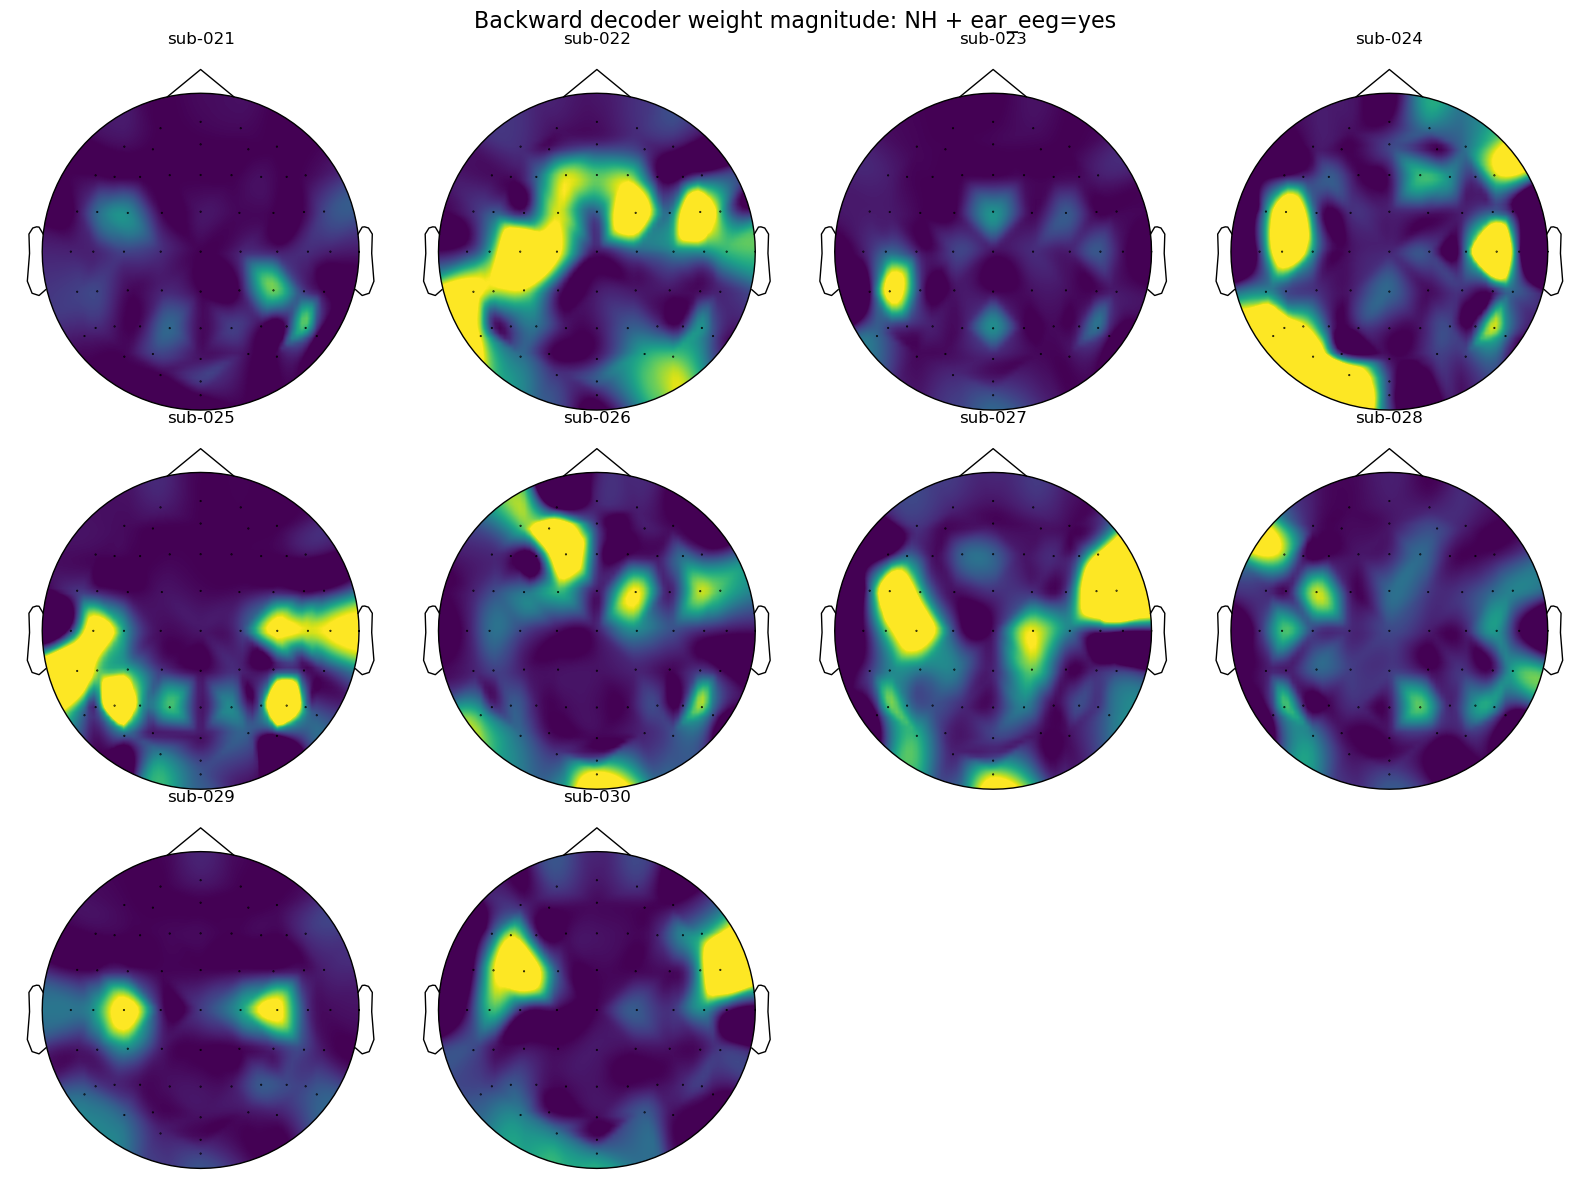

In [3]:
# -----------------------------
# 5. Create EEG montage/info
# -----------------------------

montage = mne.channels.make_standard_montage("biosemi64")

# Important:
# This is a temporary assumption.
# You should replace this with the exact channel names and order used in your model.
n_channels = len(next(iter(subject_maps.values())))
ch_names = montage.ch_names[:n_channels]

info = mne.create_info(ch_names=ch_names, sfreq=64, ch_types="eeg")
info.set_montage(montage, on_missing="ignore")

# -----------------------------
# 6. Plot topomap grid
# -----------------------------

n_subjects = len(subject_maps)

n_cols = 4
n_rows = math.ceil(n_subjects / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

# Use same color scale across all subjects
all_values = np.concatenate(list(subject_maps.values()))
vmin = np.percentile(all_values,5)
vmax = np.percentile(all_values,95)

for ax, (sub, spatial_weights) in zip(axes, subject_maps.items()):
    mne.viz.plot_topomap(
        spatial_weights,
        info,
        axes=ax,
        show=False,
        contours=0,
        cmap="viridis",
        vlim=(vmin, vmax)
    )
    ax.set_title(sub)

# Turn off unused axes
for ax in axes[len(subject_maps):]:
    ax.axis("off")

fig.suptitle(
    f"Backward decoder weight magnitude: {wanted_hearing_status.upper()} + ear_eeg={wanted_ear_eeg}",
    fontsize=16
)

plt.tight_layout()
plt.show()

Selected subjects:
['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-041', 'sub-042']
Number of subjects: 22
Number of loaded subjects: 22
Color scale:
vmin: 0.04311770037636063
vmax: 8.617960597674758


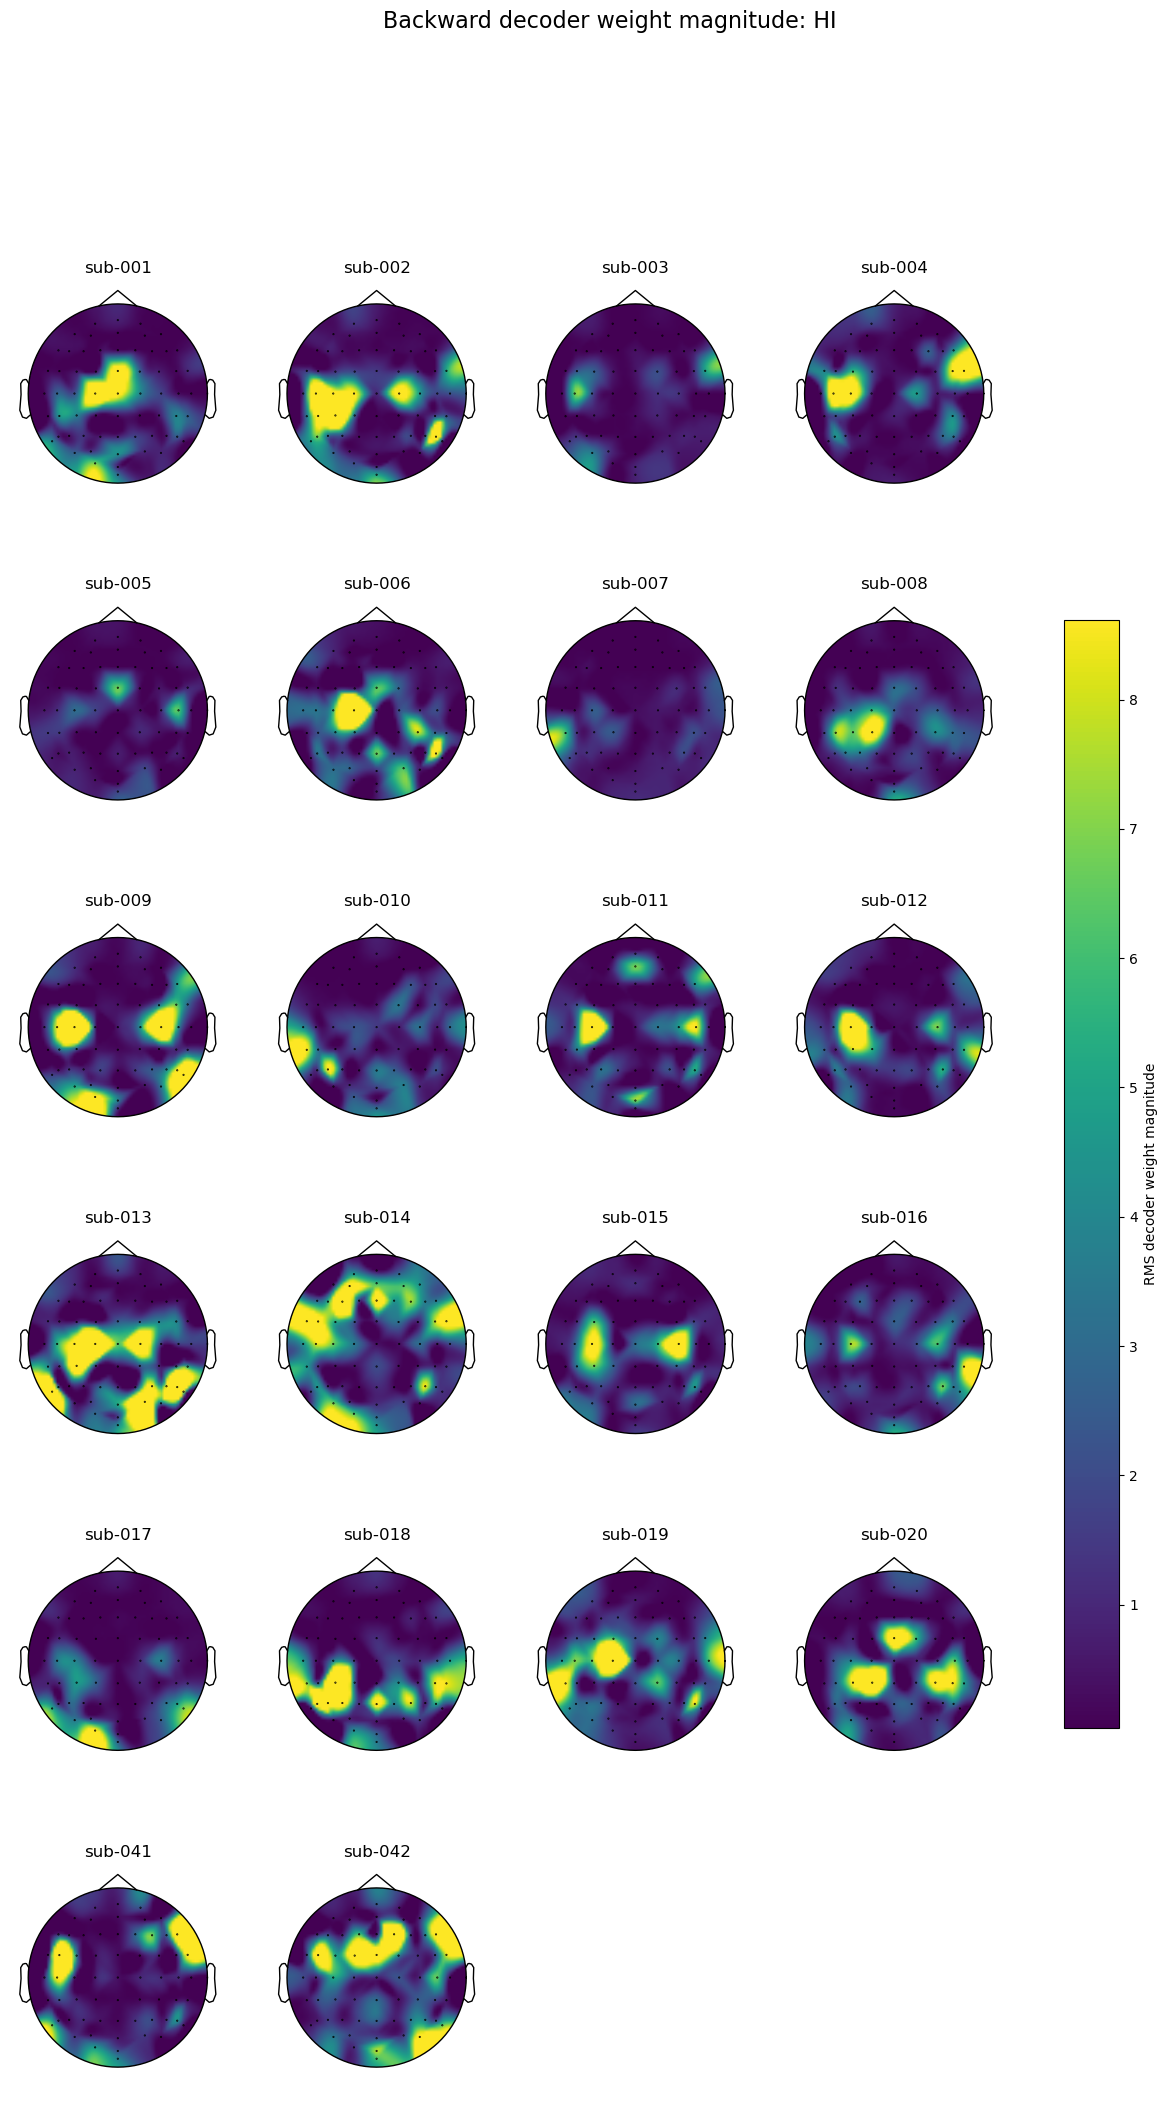

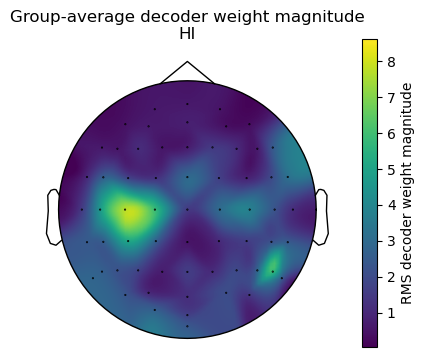

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from pathlib import Path
import math

# -----------------------------
# 1. Paths
# -----------------------------

participants_path = Path(r"C:\subset\ds-eeg-snhl\participants.tsv")
results_dir = Path(r"..\results_backward")

# -----------------------------
# 2. Choose group
# -----------------------------

# Options for hearing_status: "hi" or "nh"
wanted_hearing_status = "hi"

# -----------------------------
# 3. Load participant metadata
# -----------------------------

participants = pd.read_csv(participants_path, sep="\t")

participants["hearing_status"] = participants["hearing_status"].str.lower()

group_df = participants[
    participants["hearing_status"] == wanted_hearing_status
]

subjects = group_df["participant_id"].tolist()

print("Selected subjects:")
print(subjects)
print("Number of subjects:", len(subjects))

# -----------------------------
# 4. Load decoder weights
# -----------------------------

subject_maps = {}

for sub in subjects:
    npz_path = results_dir / sub / f"{sub}_backward_eelbrain_backward_predictions.npz"

    if not npz_path.exists():
        print("Missing file:", npz_path)
        continue

    data = np.load(npz_path)

    decoder_h = data["decoder_h"]  # expected shape: channels x lags

    # Collapse over lags to one positive value per channel
    # This gives decoder weight magnitude, not direct neural activity.
    spatial_weights = np.sqrt(np.mean(decoder_h ** 2, axis=1))

    subject_maps[sub] = spatial_weights

print("Number of loaded subjects:", len(subject_maps))

if len(subject_maps) == 0:
    raise RuntimeError("No subjects were loaded. Check paths and filters.")

# -----------------------------
# 5. Create EEG montage/info
# -----------------------------

montage = mne.channels.make_standard_montage("biosemi64")

n_channels = len(next(iter(subject_maps.values())))

# IMPORTANT:
# Replace this with the real channel names in the exact order used by the model.
# This fallback assumes the first n channels in the BioSemi64 montage.
ch_names = montage.ch_names[:n_channels]

info = mne.create_info(
    ch_names=ch_names,
    sfreq=64,
    ch_types="eeg"
)
info.set_montage(montage, on_missing="ignore")

# -----------------------------
# 6. Shared color scale
# -----------------------------

all_values = np.concatenate(list(subject_maps.values()))

vmin = np.percentile(all_values, 5)
vmax = np.percentile(all_values, 95)

print("Color scale:")
print("vmin:", vmin)
print("vmax:", vmax)

# -----------------------------
# 7. Plot individual subject topomaps
# -----------------------------

n_subjects = len(subject_maps)

n_cols = 4
n_rows = math.ceil(n_subjects / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, (sub, spatial_weights) in zip(axes, subject_maps.items()):
    im, _ = mne.viz.plot_topomap(
        spatial_weights,
        info,
        axes=ax,
        show=False,
        contours=0,
        cmap="viridis",
        vlim=(vmin, vmax)
    )
    ax.set_title(sub)

for ax in axes[len(subject_maps):]:
    ax.axis("off")

fig.suptitle(
    f"Backward decoder weight magnitude: {wanted_hearing_status.upper()}",
    fontsize=16
)

fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="RMS decoder weight magnitude")

plt.show()

# -----------------------------
# 8. Plot group-average topomap
# -----------------------------

group_matrix = np.vstack(list(subject_maps.values()))
group_average = group_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))

im, _ = mne.viz.plot_topomap(
    group_average,
    info,
    axes=ax,
    show=False,
    contours=0,
    cmap="viridis",
    vlim=(vmin, vmax)
)

ax.set_title(
    f"Group-average decoder weight magnitude\n{wanted_hearing_status.upper()}"
)

fig.colorbar(im, ax=ax, shrink=0.8, label="RMS decoder weight magnitude")

plt.show()

In [19]:
# -----------------------------
# 9. Correlate each subject with the group-average topomap
# -----------------------------

from scipy.stats import pearsonr

correlation_results = []

for sub, subject_vector in subject_maps.items():

    # Make sure both are 1D arrays
    subject_vector = np.asarray(subject_vector).ravel()
    group_vector = np.asarray(group_average).ravel()

    # Pearson correlation across electrodes
    r, p = pearsonr(subject_vector, group_vector)

    correlation_results.append({
        "subject": sub,
        "pearson_r": r,
        "p_value": p
    })

corr_df = pd.DataFrame(correlation_results)

# Sort from most similar to least similar
corr_df = corr_df.sort_values("pearson_r", ascending=False).reset_index(drop=True)

print("\nCorrelation with group-average topomap:")
print(corr_df)

most_similar_subject = corr_df.iloc[0]["subject"]
least_similar_subject = corr_df.iloc[-1]["subject"]

print("\nMost similar subject:")
print(corr_df.iloc[0])

print("\nLeast similar subject:")
print(corr_df.iloc[-1])


Correlation with group-average topomap:
    subject  pearson_r       p_value
0   sub-002   0.792574  9.995910e-15
1   sub-012   0.696870  2.245353e-10
2   sub-009   0.663783  3.037032e-09
3   sub-013   0.662398  3.363103e-09
4   sub-015   0.586706  4.343511e-07
5   sub-019   0.583611  5.162870e-07
6   sub-006   0.577893  7.072624e-07
7   sub-017   0.567672  1.223259e-06
8   sub-011   0.536550  5.820682e-06
9   sub-004   0.523213  1.084414e-05
10  sub-008   0.492755  4.085826e-05
11  sub-016   0.489808  4.614742e-05
12  sub-001   0.453323  1.907209e-04
13  sub-003   0.417826  6.561502e-04
14  sub-007   0.387365  1.709885e-03
15  sub-005   0.372866  2.615846e-03
16  sub-018   0.334872  7.303591e-03
17  sub-020   0.317880  1.112349e-02
18  sub-041   0.237616  6.076418e-02
19  sub-010   0.207786  1.022350e-01
20  sub-042   0.095824  4.550218e-01
21  sub-014   0.008310  9.484601e-01

Most similar subject:
subject       sub-002
pearson_r    0.792574
p_value           0.0
Name: 0, dtype: obj

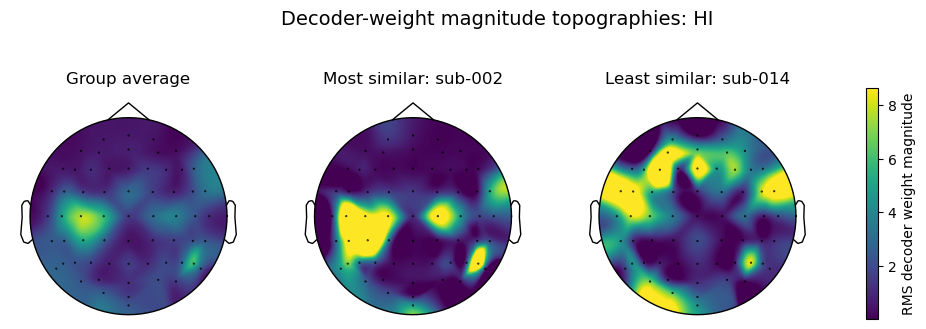

In [20]:
# -----------------------------
# 10. Plot group average, most similar, and least similar subject
# -----------------------------

maps_to_plot = {
    "Group average": group_average,
    f"Most similar: {most_similar_subject}": subject_maps[most_similar_subject],
    f"Least similar: {least_similar_subject}": subject_maps[least_similar_subject],
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (title, values) in zip(axes, maps_to_plot.items()):
    im, _ = mne.viz.plot_topomap(
        values,
        info,
        axes=ax,
        show=False,
        contours=0,
        cmap="viridis",
        vlim=(vmin, vmax)
    )
    ax.set_title(title)

fig.suptitle(
    f"Decoder-weight magnitude topographies: {wanted_hearing_status.upper()}",
    fontsize=14
)

fig.colorbar(
    im,
    ax=axes.tolist(),
    shrink=0.75,
    label="RMS decoder weight magnitude"
)

plt.show()

Selected subjects:
['sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-043', 'sub-044']
Number of subjects: 22
Number of loaded subjects: 22
Color scale:
vmin: 0.013735376482000048
vmax: 3.100771696695812


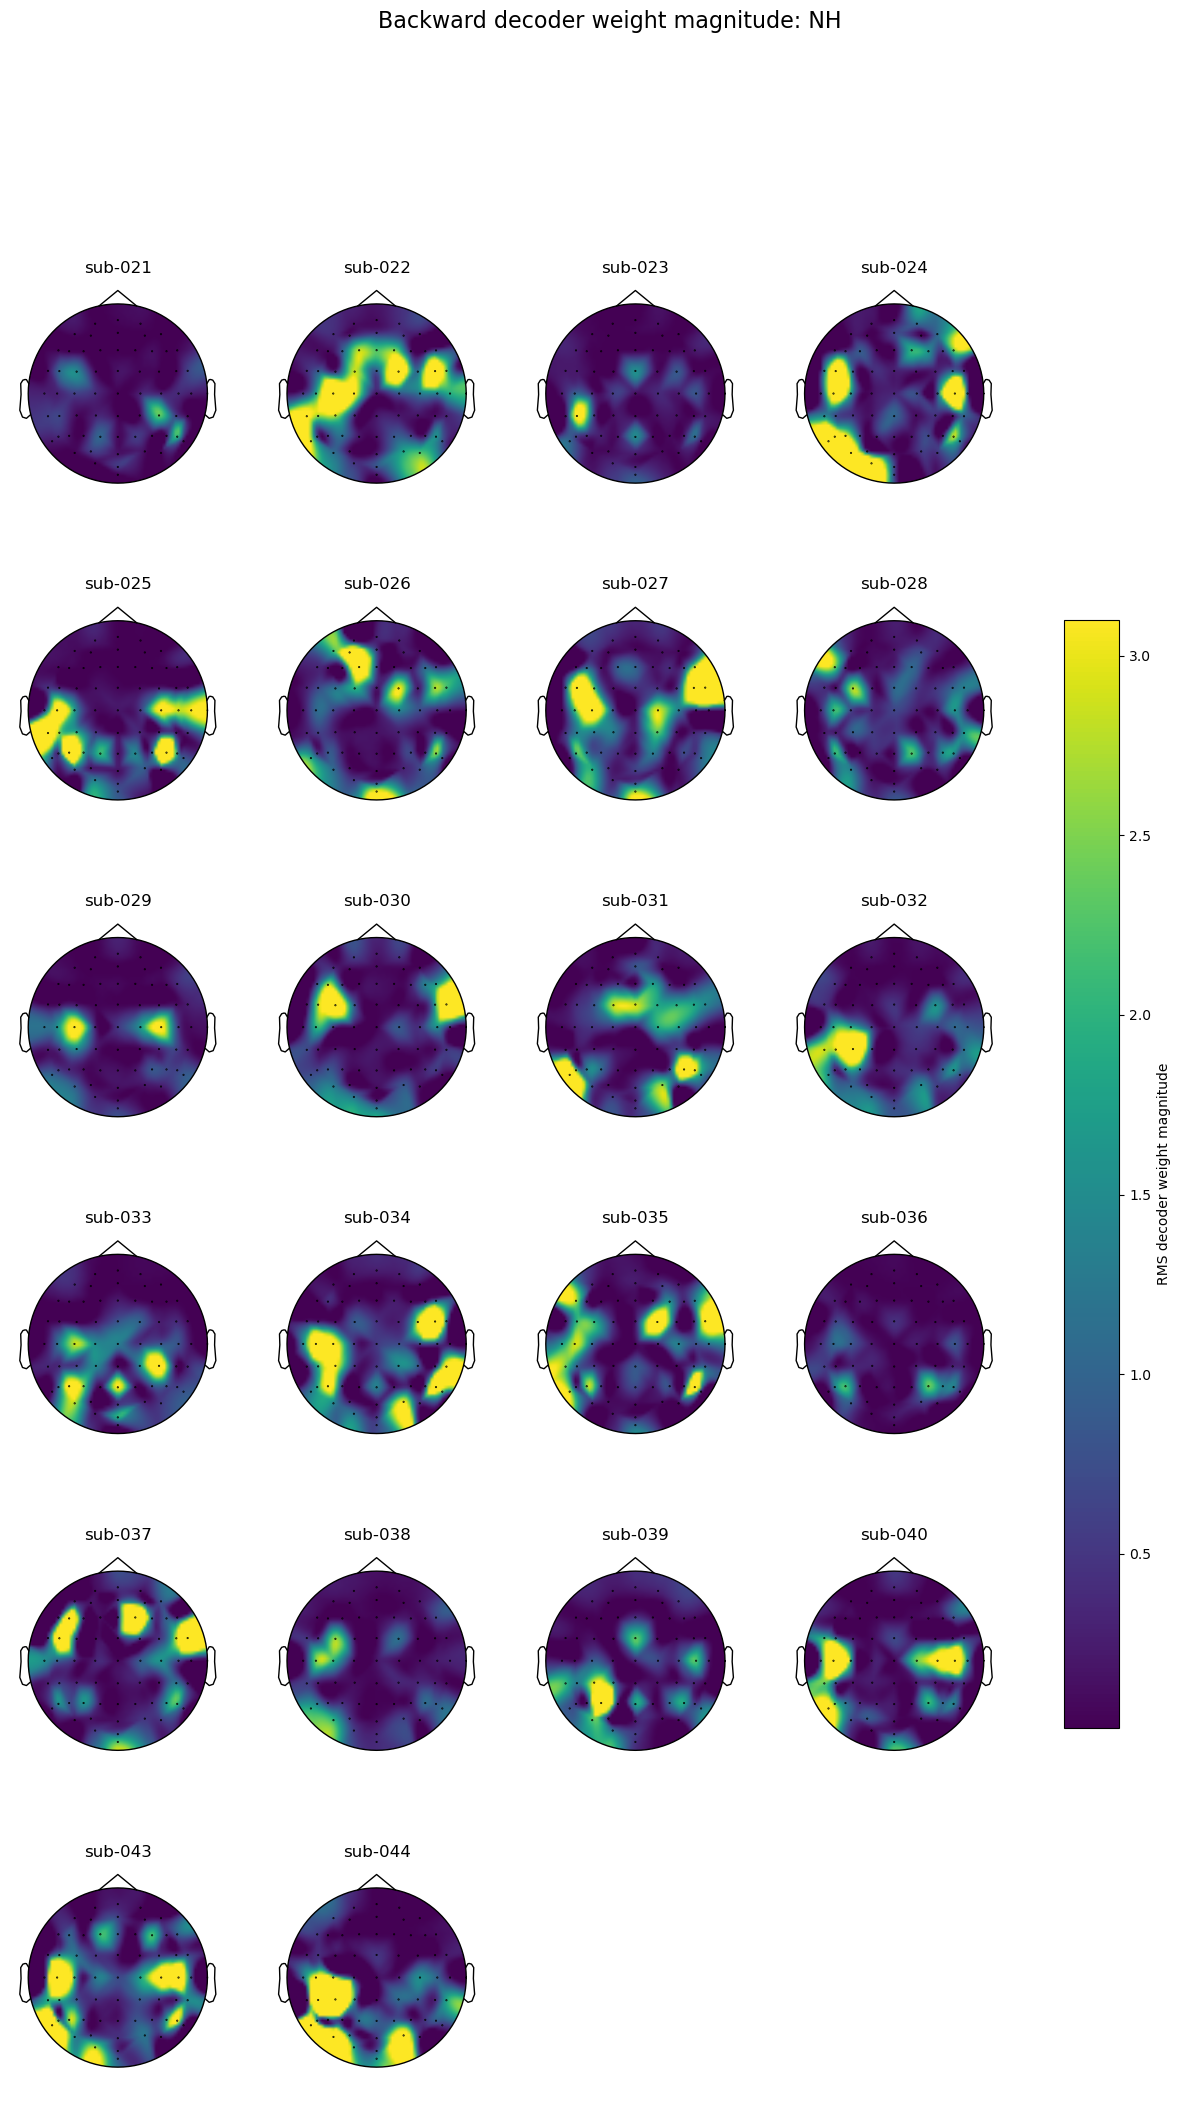

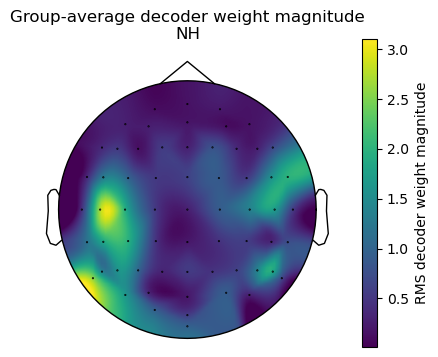

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from pathlib import Path
import math

# -----------------------------
# 1. Paths
# -----------------------------

participants_path = Path(r"C:\subset\ds-eeg-snhl\participants.tsv")
results_dir = Path(r"..\results_backward")

# -----------------------------
# 2. Choose group
# -----------------------------

# Options for hearing_status: "hi" or "nh"
wanted_hearing_status = "nh"

# -----------------------------
# 3. Load participant metadata
# -----------------------------

participants = pd.read_csv(participants_path, sep="\t")

participants["hearing_status"] = participants["hearing_status"].str.lower()

group_df = participants[
    participants["hearing_status"] == wanted_hearing_status
]

subjects = group_df["participant_id"].tolist()

print("Selected subjects:")
print(subjects)
print("Number of subjects:", len(subjects))

# -----------------------------
# 4. Load decoder weights
# -----------------------------

subject_maps = {}

for sub in subjects:
    npz_path = results_dir / sub / f"{sub}_backward_eelbrain_backward_predictions.npz"

    if not npz_path.exists():
        print("Missing file:", npz_path)
        continue

    data = np.load(npz_path)

    decoder_h = data["decoder_h"]  # expected shape: channels x lags

    # Collapse over lags to one positive value per channel
    # This gives decoder weight magnitude, not direct neural activity.
    spatial_weights = np.sqrt(np.mean(decoder_h ** 2, axis=1))

    subject_maps[sub] = spatial_weights

print("Number of loaded subjects:", len(subject_maps))

if len(subject_maps) == 0:
    raise RuntimeError("No subjects were loaded. Check paths and filters.")

# -----------------------------
# 5. Create EEG montage/info
# -----------------------------

montage = mne.channels.make_standard_montage("biosemi64")

n_channels = len(next(iter(subject_maps.values())))

# IMPORTANT:
# Replace this with the real channel names in the exact order used by the model.
# This fallback assumes the first n channels in the BioSemi64 montage.
ch_names = montage.ch_names[:n_channels]

info = mne.create_info(
    ch_names=ch_names,
    sfreq=64,
    ch_types="eeg"
)
info.set_montage(montage, on_missing="ignore")

# -----------------------------
# 6. Shared color scale
# -----------------------------

all_values = np.concatenate(list(subject_maps.values()))

vmin = np.percentile(all_values, 5)
vmax = np.percentile(all_values, 95)

print("Color scale:")
print("vmin:", vmin)
print("vmax:", vmax)

# -----------------------------
# 7. Plot individual subject topomaps
# -----------------------------

n_subjects = len(subject_maps)

n_cols = 4
n_rows = math.ceil(n_subjects / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, (sub, spatial_weights) in zip(axes, subject_maps.items()):
    im, _ = mne.viz.plot_topomap(
        spatial_weights,
        info,
        axes=ax,
        show=False,
        contours=0,
        cmap="viridis",
        vlim=(vmin, vmax)
    )
    ax.set_title(sub)

for ax in axes[len(subject_maps):]:
    ax.axis("off")

fig.suptitle(
    f"Backward decoder weight magnitude: {wanted_hearing_status.upper()}",
    fontsize=16
)

fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="RMS decoder weight magnitude")

plt.show()

# -----------------------------
# 8. Plot group-average topomap
# -----------------------------

group_matrix = np.vstack(list(subject_maps.values()))
group_average = group_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))

im, _ = mne.viz.plot_topomap(
    group_average,
    info,
    axes=ax,
    show=False,
    contours=0,
    cmap="viridis",
    vlim=(vmin, vmax)
)

ax.set_title(
    f"Group-average decoder weight magnitude\n{wanted_hearing_status.upper()}"
)

fig.colorbar(im, ax=ax, shrink=0.8, label="RMS decoder weight magnitude")

plt.show()

In [16]:
# -----------------------------
# 9. Correlate each subject with the group-average topomap
# -----------------------------

from scipy.stats import pearsonr

correlation_results = []

for sub, subject_vector in subject_maps.items():

    # Make sure both are 1D arrays
    subject_vector = np.asarray(subject_vector).ravel()
    group_vector = np.asarray(group_average).ravel()

    # Pearson correlation across electrodes
    r, p = pearsonr(subject_vector, group_vector)

    correlation_results.append({
        "subject": sub,
        "pearson_r": r,
        "p_value": p
    })

corr_df = pd.DataFrame(correlation_results)

# Sort from most similar to least similar
corr_df = corr_df.sort_values("pearson_r", ascending=False).reset_index(drop=True)

print("\nCorrelation with group-average topomap:")
print(corr_df)

most_similar_subject = corr_df.iloc[0]["subject"]
least_similar_subject = corr_df.iloc[-1]["subject"]

print("\nMost similar subject:")
print(corr_df.iloc[0])

print("\nLeast similar subject:")
print(corr_df.iloc[-1])


Correlation with group-average topomap:
    subject  pearson_r       p_value
0   sub-043   0.734891  7.044123e-12
1   sub-040   0.624507  4.509393e-08
2   sub-034   0.620141  5.948623e-08
3   sub-032   0.603843  1.613098e-07
4   sub-024   0.596580  2.471916e-07
5   sub-038   0.587439  4.168006e-07
6   sub-035   0.554886  2.366582e-06
7   sub-044   0.521779  1.157653e-05
8   sub-029   0.517254  1.419950e-05
9   sub-025   0.512233  1.775209e-05
10  sub-022   0.493771  3.916773e-05
11  sub-027   0.457192  1.653070e-04
12  sub-036   0.454482  1.827540e-04
13  sub-031   0.445584  2.526008e-04
14  sub-023   0.430158  4.336881e-04
15  sub-028   0.414799  7.246155e-04
16  sub-030   0.403391  1.044711e-03
17  sub-037   0.279615  2.645886e-02
18  sub-021   0.264517  3.617405e-02
19  sub-033   0.258199  4.103893e-02
20  sub-039   0.257157  4.189111e-02
21  sub-026   0.197686  1.204159e-01

Most similar subject:
subject       sub-043
pearson_r    0.734891
p_value           0.0
Name: 0, dtype: obj

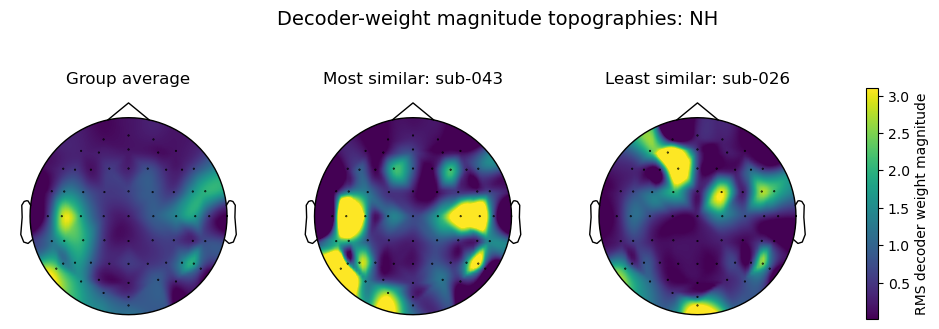

In [17]:
# -----------------------------
# 10. Plot group average, most similar, and least similar subject
# -----------------------------

maps_to_plot = {
    "Group average": group_average,
    f"Most similar: {most_similar_subject}": subject_maps[most_similar_subject],
    f"Least similar: {least_similar_subject}": subject_maps[least_similar_subject],
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (title, values) in zip(axes, maps_to_plot.items()):
    im, _ = mne.viz.plot_topomap(
        values,
        info,
        axes=ax,
        show=False,
        contours=0,
        cmap="viridis",
        vlim=(vmin, vmax)
    )
    ax.set_title(title)

fig.suptitle(
    f"Decoder-weight magnitude topographies: {wanted_hearing_status.upper()}",
    fontsize=14
)

fig.colorbar(
    im,
    ax=axes.tolist(),
    shrink=0.75,
    label="RMS decoder weight magnitude"
)

plt.show()


Group: HI
Selected subjects:
['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-041', 'sub-042']
Number of subjects: 22
Number of loaded subjects: 22

Group: NH
Selected subjects:
['sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-043', 'sub-044']
Number of subjects: 22
Number of loaded subjects: 22

Group: HI
Correlation with group-average topomap:
    subject  pearson_r       p_value
0   sub-002   0.792574  9.995910e-15
1   sub-012   0.696870  2.245353e-10
2   sub-009   0.663783  3.037032e-09
3   sub-013   0.662398  3.363103e-09
4   sub-015   0.586706  4.343511e-07
5   sub-019   0.583611  5.162870e-07
6   sub-006   0.577893  7.072624e-07
7

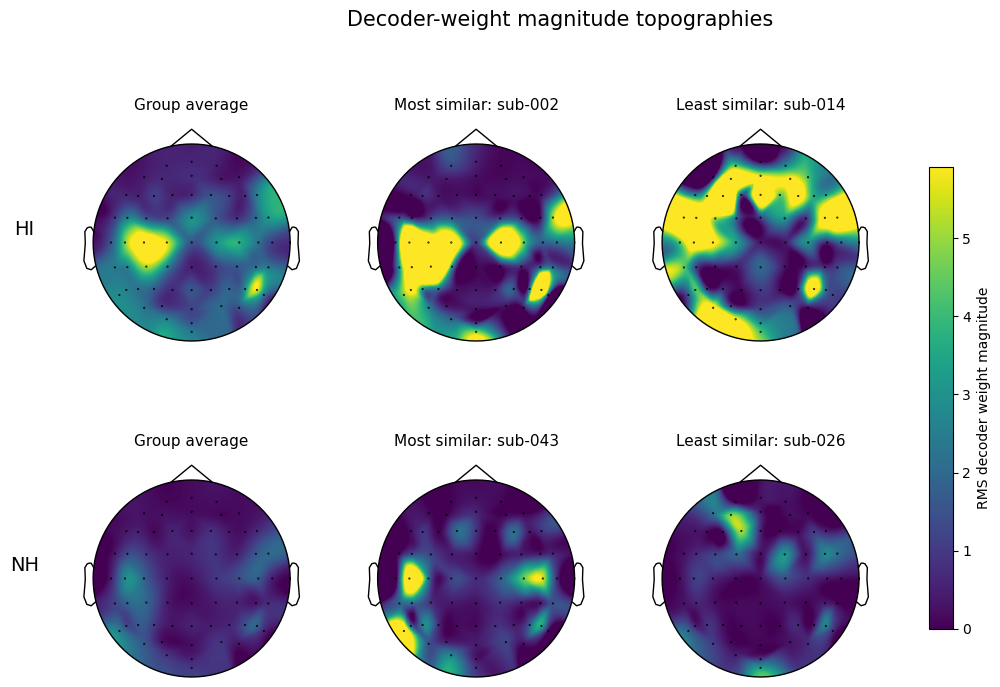

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from pathlib import Path
from scipy.stats import pearsonr

# -----------------------------
# 1. Paths
# -----------------------------

participants_path = Path(r"C:\subset\ds-eeg-snhl\participants.tsv")
results_dir = Path(r"..\results_backward")

# -----------------------------
# 2. Load participant metadata
# -----------------------------

participants = pd.read_csv(participants_path, sep="\t")
participants["hearing_status"] = participants["hearing_status"].str.lower()

# Groups to plot
groups = ["hi", "nh"]

# -----------------------------
# 3. Load decoder RMS maps for both groups
# -----------------------------

subject_maps_by_group = {}

for wanted_hearing_status in groups:

    group_df = participants[
        participants["hearing_status"] == wanted_hearing_status
    ]

    subjects = group_df["participant_id"].tolist()

    print("\n====================================")
    print("Group:", wanted_hearing_status.upper())
    print("Selected subjects:")
    print(subjects)
    print("Number of subjects:", len(subjects))

    subject_maps = {}

    for sub in subjects:
        npz_path = results_dir / sub / f"{sub}_backward_eelbrain_backward_predictions.npz"

        if not npz_path.exists():
            print("Missing file:", npz_path)
            continue

        data = np.load(npz_path, allow_pickle=True)

        decoder_h = data["decoder_h"]  # expected shape: channels x lags

        # RMS across all lags
        # This gives one positive decoder-weight magnitude per electrode.
        spatial_weights = np.sqrt(np.mean(decoder_h ** 2, axis=1))

        subject_maps[sub] = spatial_weights

    print("Number of loaded subjects:", len(subject_maps))

    if len(subject_maps) == 0:
        raise RuntimeError(f"No subjects were loaded for group {wanted_hearing_status}.")

    subject_maps_by_group[wanted_hearing_status] = subject_maps

# -----------------------------
# 4. Create EEG montage/info
# -----------------------------

montage = mne.channels.make_standard_montage("biosemi64")

# Get number of channels from first loaded subject
first_group = groups[0]
first_subject_vector = next(iter(subject_maps_by_group[first_group].values()))
n_channels = len(first_subject_vector)

# IMPORTANT:
# Replace this with the real channel names in the exact order used by the model.
# This fallback assumes the first n channels in the BioSemi64 montage.
ch_names = montage.ch_names[:n_channels]

info = mne.create_info(
    ch_names=ch_names,
    sfreq=64,
    ch_types="eeg"
)

info.set_montage(montage, on_missing="ignore")

# -----------------------------
# 5. Compute group averages and subject correlations
# -----------------------------

summary_by_group = {}

for group_name, subject_maps in subject_maps_by_group.items():

    group_matrix = np.vstack(list(subject_maps.values()))
    group_average = group_matrix.mean(axis=0)

    correlation_results = []

    for sub, subject_vector in subject_maps.items():
        subject_vector = np.asarray(subject_vector).ravel()
        group_vector = np.asarray(group_average).ravel()

        r, p = pearsonr(subject_vector, group_vector)

        correlation_results.append({
            "subject": sub,
            "pearson_r": r,
            "p_value": p
        })

    corr_df = pd.DataFrame(correlation_results)
    corr_df = corr_df.sort_values("pearson_r", ascending=False).reset_index(drop=True)

    most_similar_subject = corr_df.iloc[0]["subject"]
    least_similar_subject = corr_df.iloc[-1]["subject"]

    summary_by_group[group_name] = {
        "group_average": group_average,
        "corr_df": corr_df,
        "most_similar_subject": most_similar_subject,
        "least_similar_subject": least_similar_subject
    }

    print("\n====================================")
    print("Group:", group_name.upper())
    print("Correlation with group-average topomap:")
    print(corr_df)

    print("\nMost similar subject:")
    print(corr_df.iloc[0])

    print("\nLeast similar subject:")
    print(corr_df.iloc[-1])

# -----------------------------
# 6. Shared color scale across HI and NH
# -----------------------------

# Include all subject maps and group-average maps from both groups
all_values = []

for group_name, subject_maps in subject_maps_by_group.items():
    for values in subject_maps.values():
        all_values.append(values)

    all_values.append(summary_by_group[group_name]["group_average"])

all_values = np.concatenate(all_values)

# Robust shared scale:
# Use 95th percentile to avoid one extreme subject dominating the color scale.
vmin = 0
vmax = np.percentile(all_values, 95)

print("\n====================================")
print("Shared color scale across HI and NH")
print("vmin:", vmin)
print("vmax:", vmax)

# -----------------------------
# 7. Plot HI and NH using same color scale
# -----------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13, 8)
)

for row_idx, group_name in enumerate(groups):

    group_summary = summary_by_group[group_name]
    subject_maps = subject_maps_by_group[group_name]

    group_average = group_summary["group_average"]
    most_similar_subject = group_summary["most_similar_subject"]
    least_similar_subject = group_summary["least_similar_subject"]

    maps_to_plot = [
        ("Group average", group_average),
        (
            f"Most similar: {most_similar_subject}",
            subject_maps[most_similar_subject]
        ),
        (
            f"Least similar: {least_similar_subject}",
            subject_maps[least_similar_subject]
        )
    ]

    for col_idx, (title, values) in enumerate(maps_to_plot):

        ax = axes[row_idx, col_idx]

        im, _ = mne.viz.plot_topomap(
            values,
            info,
            axes=ax,
            show=False,
            contours=0,
            cmap="viridis",
            vlim=(vmin, vmax)
        )

        ax.set_title(title, fontsize=11)

    # Add group label on the left
    axes[row_idx, 0].set_ylabel(
        group_name.upper(),
        fontsize=14,
        rotation=0,
        labelpad=35,
        va="center"
    )

fig.suptitle(
    "Decoder-weight magnitude topographies",
    fontsize=15
)

# One shared colorbar for both groups
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.75,
    label="RMS decoder weight magnitude"
)

plt.show()